In [2]:
import pandas as pd
from sqlalchemy import create_engine, text
from stock_forecast.DATA.stock_invest_function import *

C:\Users\Hoyoung_Park\PyCharmMiscProject\.venv1\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
TABLE_NAME = "korea_monthly_trade_forecast_v2"

def make_pivot_from_trade_forecast_db(
    engine,
    forecast_dates: list,
    indicator: str,
    table_name: str = TABLE_NAME,
    aggfunc: str = "last"   # 중복 시 처리: "last" / "sum" 등
) -> pd.DataFrame:
    """
    forecast_dates(리스트) + indicator 조건으로 DB에서 데이터 조회 후
    index=date, columns=hs_code, values=value pivot 생성
    """

    if not forecast_dates:
        raise ValueError("forecast_dates 리스트가 비어 있습니다.")

    # MySQL IN 절용 placeholder 생성
    placeholders = ", ".join([f":d{i}" for i in range(len(forecast_dates))])
    params = {f"d{i}": forecast_dates[i] for i in range(len(forecast_dates))}
    params["indicator"] = indicator

    sql = text(f"""
        SELECT date, hs_code, value
        FROM {table_name}
        WHERE forecast_date IN ({placeholders})
          AND indicator = :indicator
    """)

    with engine.connect() as conn:
        df = pd.read_sql(sql, conn, params=params)

    if df.empty:
        raise ValueError("조건에 해당하는 데이터가 없습니다. forecast_dates/indicator를 확인하세요.")

    # 타입 정리
    df["date"] = pd.to_datetime(df["date"])
    df["hs_code"] = df["hs_code"].astype(str)

    # pivot
    pivot_df = (
        df.pivot_table(
            index="date",
            columns="hs_code",
            values="value",
            aggfunc=aggfunc  # 중복 시 마지막 값/합계 등 선택
        )
        .sort_index()
    )

    return pivot_df

import pandas as pd

def compare_period_sum_by_hscode(
    last_month_pivot_df: pd.DataFrame,
    this_month_pivot_df: pd.DataFrame,
    fill_value: float = 0.0,
    pct_mode: str = "last"   # "last" or "this"
) -> pd.DataFrame:
    """
    last_month_pivot_df, this_month_pivot_df:
      - index: date (기간)
      - columns: hs_code
      - values: 금액/지표

    반환:
      index: hs_code
      columns: last_sum, this_sum, diff, pct_change
    """
    if pct_mode not in ("last", "this"):
        raise ValueError("pct_mode must be 'last' or 'this'")

    # 1) 기간 합계 (hs_code별)
    last_sum = last_month_pivot_df.sum(axis=0, skipna=True)
    this_sum = this_month_pivot_df.sum(axis=0, skipna=True)

    # 2) hs_code 정렬/정합 (없는 hs_code는 fill_value로)
    all_codes = last_sum.index.union(this_sum.index)
    last_sum = last_sum.reindex(all_codes).fillna(fill_value)
    this_sum = this_sum.reindex(all_codes).fillna(fill_value)

    # 3) 차이 및 변화율
    diff = this_sum - last_sum

    denom = last_sum if pct_mode == "last" else this_sum
    denom = denom.replace(0, np.nan)           # 0으로 나누기 방지
    pct_change = diff / denom

    result = pd.DataFrame({
        "last_sum": last_sum,
        "this_sum": this_sum,
        "diff": diff,
        "pct_change": pct_change
    })
    result.index.name = "hs_code"

    # 보기 좋게: 변화율 기준 내림차순 정렬(원하면 제거)
    result = result.sort_values("pct_change", ascending=False)

    return result

def hs_growth_prev_next_12m(
    concated_df: pd.DataFrame,
    center_date: str,
    prev_months: int = 12,
    next_months: int = 12,
    include_center_in_prev: bool = False,  # True면 center월을 과거합에 포함
    drop_nonpositive_prev: bool = True,    # prev합 <=0 이면 NaN 처리
    min_valid_months: int = 8,             # 윈도우 내 유효 월 최소개수(너무 결측이면 제외)
) -> pd.DataFrame:
    """
    concated_df:
      - index: date (DatetimeIndex)
      - columns: hs_code (str/int 혼재 가능)
      - values: export value (float)

    return:
      columns = [hs_code, sum_prev_12m, sum_next_12m, pct_change, n_prev, n_next]
      pct_change = (sum_next / sum_prev) - 1
    """

    df = concated_df.copy()

    # 1) index 정리
    if not isinstance(df.index, pd.DatetimeIndex):
        df.index = pd.to_datetime(df.index)
    df = df.sort_index()

    # 2) 기준일을 월말 기준으로 정규화(월별 데이터라면 이게 안전)
    c = pd.to_datetime(center_date)
    c = (c + pd.offsets.MonthEnd(0)).normalize()

    # 3) 윈도우 범위 설정
    prev_start = (c - pd.DateOffset(months=prev_months)) + pd.offsets.MonthEnd(0)
    prev_end   = c if include_center_in_prev else (c - pd.DateOffset(months=1)) + pd.offsets.MonthEnd(0)

    next_start = (c + pd.DateOffset(months=1)) + pd.offsets.MonthEnd(0)
    next_end   = (c + pd.DateOffset(months=next_months)) + pd.offsets.MonthEnd(0)

    # 4) 슬라이싱 (존재하지 않는 월은 자동으로 빠짐)
    prev_win = df.loc[(df.index >= prev_start) & (df.index <= prev_end)]
    next_win = df.loc[(df.index >= next_start) & (df.index <= next_end)]

    # 5) 합계 + 유효 관측치 수
    sum_prev = prev_win.sum(axis=0, min_count=1)
    sum_next = next_win.sum(axis=0, min_count=1)

    n_prev = prev_win.notna().sum(axis=0)
    n_next = next_win.notna().sum(axis=0)

    # 6) 너무 결측이 많으면 제외(선택)
    sum_prev = sum_prev.where(n_prev >= min_valid_months)
    sum_next = sum_next.where(n_next >= min_valid_months)

    # 7) 분모 0/음수 제거(선택)
    if drop_nonpositive_prev:
        sum_prev = sum_prev.where(sum_prev > 0)

    pct = (sum_next / sum_prev) - 1

    # 8) 결과 DF
    out = pd.DataFrame({
        "hs_code": sum_prev.index.astype(str),
        "sum_prev_12m": sum_prev.values,
        "sum_next_12m": sum_next.values,
        "pct_change": pct.values,
        "n_prev": n_prev.values,
        "n_next": n_next.values,
    })

    out = out.dropna(subset=["pct_change"]).sort_values("pct_change", ascending=False).reset_index(drop=True)
    return out


In [4]:
db_info = {
    'host': get_db_host(),
    # 'host' : 'hystox74.synology.me',
    'port': 3307,
    'user': 'stox7412',
    'password': 'Apt106503!~',
    'database': 'investar'
}

engine = create_engine(
    f"mysql+pymysql://{db_info['user']}:{db_info['password']}@"
    f"{db_info['host']}:{db_info['port']}/{db_info['database']}"
)

query = text("""
    SELECT DISTINCT forecast_date
    FROM korea_monthly_trade_forecast_v2
    ORDER BY forecast_date
""")

with engine.connect() as conn:
    forecast_dates = pd.read_sql(query, conn)

print(forecast_dates)

   forecast_date
0     2025-10-31
1     2025-11-02
2     2025-11-03
3     2025-11-11
4     2025-11-12
5     2025-11-13
6     2025-12-09
7     2025-12-10
8     2025-12-12
9     2025-12-13
10    2026-01-14
11    2026-02-20
12    2026-02-21


In [6]:
trade_df = fetch_table_data(db_info, 'korea_monthly_trade_data')

# date를 datetime으로 보장
trade_df["date"] = pd.to_datetime(trade_df["date"])

# expDlr만 필터링
exp_df = trade_df[trade_df["indicator"] == "expDlr"]

# pivot table 생성
trail_trade_df = (
    exp_df
    .pivot_table(
        index="date",
        columns="root_hs_code",
        values="value",
        aggfunc="last"   # 동일 date-hs_code 중복 시 마지막 값
    )
    .sort_index()
)

trail_trade_df.head()

✅ 'korea_monthly_trade_data' 테이블에서 1126582건의 데이터를 가져왔습니다.


root_hs_code,1201,121120,1212,121221,151550,1515500000,151590,1515901000,1518,1604,...,940330,940340,9405,940540,9405409000,950300,9503002100,961610,961900,970191
date,,,,,,,,,,,,,,,,,,,,,
2007-01-31,NaN,2018940.0,NaN,NaN,31817.0,NaN,116532.0,NaN,NaN,NaN,...,2108610.0,NaN,NaN,2653160.0,NaN,5251580.0,NaN,NaN,NaN,NaN
2007-02-28,NaN,1176640.0,NaN,NaN,14812.0,NaN,107603.0,NaN,NaN,NaN,...,1737240.0,NaN,NaN,786606.0,NaN,4862580.0,NaN,NaN,NaN,NaN
2007-03-31,NaN,4366480.0,NaN,NaN,35485.0,NaN,93938.0,NaN,NaN,NaN,...,2580450.0,NaN,NaN,1709200.0,NaN,6616860.0,NaN,NaN,NaN,NaN
2007-04-30,NaN,2862930.0,NaN,NaN,10386.0,NaN,100627.0,NaN,NaN,NaN,...,2908640.0,NaN,NaN,1551490.0,NaN,6109910.0,NaN,NaN,NaN,NaN
2007-05-31,NaN,2797800.0,NaN,NaN,16392.0,NaN,56320.0,NaN,NaN,NaN,...,2390120.0,NaN,NaN,1840860.0,NaN,6854090.0,NaN,NaN,NaN,NaN


<Axes: xlabel='date'>

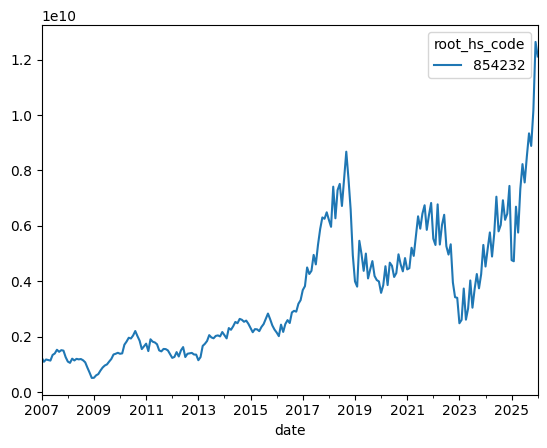

In [9]:
trail_trade_df[['854232']].plot()

In [10]:
forecast_dates = ["2026-01-14"]
indicator = "sarima_expDlr"

last_month_pivot_df = make_pivot_from_trade_forecast_db(
    engine=engine,
    forecast_dates=forecast_dates,
    indicator=indicator,
    aggfunc="last"
)



In [11]:
target_date = "2027-12-31"

# index가 datetime인 경우를 가정
target_date = pd.to_datetime(target_date)

# 해당 날짜에서 NaN인 컬럼 drop
df_filtered = last_month_pivot_df.loc[:, ~last_month_pivot_df.loc[target_date].isna()]

last_month_forecast = df_filtered.loc['2026-01':]

In [13]:
last_month_forecast[['854232']]

hs_code,854232
date,
2026-01-31,1.152001e+10
2026-02-28,1.206198e+10
2026-03-31,1.355275e+10
2026-04-30,1.283659e+10
2026-05-31,1.403778e+10
2026-06-30,1.524325e+10
2026-07-31,1.443950e+10
2026-08-31,1.509637e+10
2026-09-30,1.597428e+10


In [14]:
forecast_dates = ["2026-02-20"]
indicator = "sarima_expDlr"

this_month_pivot_df = make_pivot_from_trade_forecast_db(
    engine=engine,
    forecast_dates=forecast_dates,
    indicator=indicator,
    aggfunc="last"
)

target_date = "2027-12-31"

# index가 datetime인 경우를 가정
target_date = pd.to_datetime(target_date)

# 해당 날짜에서 NaN인 컬럼 drop
this_month_df_filtered = this_month_pivot_df.loc[:, ~this_month_pivot_df.loc[target_date].isna()]

this_month_forecast = this_month_df_filtered.loc['2025-12':]

In [17]:
this_month_forecast[['8542']]

KeyError: "None of [Index(['8542'], dtype='object', name='hs_code')] are in the [columns]"

In [9]:
change_results = compare_period_sum_by_hscode(last_month_pivot_df, this_month_pivot_df)

In [10]:
# change_results.to_csv(r'C:\Users\82108\OneDrive\바탕 화면\investment\investment_strategy\DATA\export_growth_change.csv', index=True, encoding='utf-8-sig')

In [12]:
change_results

,last_sum,this_sum,diff,pct_change
hs_code,,,,
1201,2.590915e+05,2.590915e+05,0.0,0.0
8473,5.852182e+10,5.852182e+10,0.0,0.0
841830,3.841037e+06,3.841037e+06,0.0,0.0
841840,1.525109e+07,1.525109e+07,0.0,0.0
841869,5.406319e+08,5.406319e+08,0.0,0.0
...,...,...,...,...
481910,1.371162e+08,1.371162e+08,0.0,0.0
4901,6.543593e+08,6.543593e+08,0.0,0.0
490199,5.491838e+08,5.491838e+08,0.0,0.0


### 주요기업 주력 상품 수출 증가율 조회

In [77]:
company_df = fetch_table_data(db_info, 'korea_company_hscode_map')
company_df = company_df.rename(columns={'hs_code' : 'root_hs_code'})
company_df

✅ 'korea_company_hscode_map' 테이블에서 762건의 데이터를 가져왔습니다.


,ticker,Name,root_hs_code
0,A093370,후성,854321
1,A036490,SK머티리얼즈,281290
2,A036490,SK머티리얼즈,8542
3,A104830,원익머트리얼즈,854239
4,A144960,뉴파워프라즈마,854239
...,...,...,...
757,A011784,금호석유,4002590000
758,A011785,금호석유,4002110000
759,A178920,PI첨단소재,3916909000
760,A000070,삼양홀딩스,290723


In [78]:
center_date = '2025-11-30'

concated_df = pd.concat([trail_trade_df, this_month_forecast], join="inner")

growth_df = hs_growth_prev_next_12m(
    concated_df=concated_df,
    center_date=center_date,
    prev_months=12,
    next_months=12,
    include_center_in_prev=False,
    drop_nonpositive_prev=True,
    min_valid_months=10
)

In [80]:
# key dtype 통일 (문자열)
company_df = company_df.copy()
growth_df  = growth_df.copy()

company_df["root_hs_code"] = company_df["root_hs_code"].astype(str).str.strip()
growth_df["hs_code"]       = growth_df["hs_code"].astype(str).str.strip()

merged_df = company_df.merge(
    growth_df,
    how="left",
    left_on="root_hs_code",
    right_on="hs_code"
)

merged_df

,ticker,Name,root_hs_code,hs_code,sum_prev_12m,sum_next_12m,pct_change,n_prev,n_next
0,A093370,후성,854321,NaN,NaN,NaN,NaN,NaN,NaN
1,A036490,SK머티리얼즈,281290,281290,1.713039e+08,2.023554e+08,0.181266,12.0,12.0
2,A036490,SK머티리얼즈,8542,8542,1.342471e+11,1.903304e+11,0.417762,12.0,12.0
3,A104830,원익머트리얼즈,854239,854239,1.107277e+10,1.060894e+10,-0.041889,12.0,12.0
4,A144960,뉴파워프라즈마,854239,854239,1.107277e+10,1.060894e+10,-0.041889,12.0,12.0
...,...,...,...,...,...,...,...,...,...
757,A011784,금호석유,4002590000,4002590000,2.621739e+08,2.551463e+08,-0.026805,12.0,12.0
758,A011785,금호석유,4002110000,4002110000,6.569550e+07,6.230046e+07,-0.051678,12.0,12.0
759,A178920,PI첨단소재,3916909000,3916909000,2.374569e+07,2.352036e+07,-0.009489,12.0,12.0
760,A000070,삼양홀딩스,290723,290723,2.849690e+08,3.051129e+08,0.070688,12.0,12.0
